In [2]:
import sys
sys.path.insert(0, "../lib")  # add lib path to search list
# IMPORTS
import stim
import numpy as np
from visulise_lattice import plot_surface_code
from mwpm import build_mwpm_decoder, measure_logical, exec_mwpm
from utils import *
# import pymatching
# import sinter
print(stim.__version__)

1.15.0


# Import Surface Code Circuit

In [40]:
surface_code_unrotated_z = stim.Circuit.from_file("/home/samir/research/experiments/surface_code_simulations/circuits/surface_code_unrotated_z.stim")
surface_code_unrotated_x = stim.Circuit.from_file("/home/samir/research/experiments/surface_code_simulations/circuits/surface_code_unrotated_x.stim")



surface_code = surface_code_unrotated_z

In [41]:
# surface_code = stim.Circuit.generated(
#     "surface_code:unrotated_memory_z",
#     distance=3,
#     rounds=1,
#     after_clifford_depolarization=0,
#     after_reset_flip_probability=0,
#     before_measure_flip_probability=0,
#     before_round_data_depolarization=0
# )



# # # # surface_code.insert(27, stim.CircuitInstruction("Z_ERROR(1) 20"))
# # # # surface_code.append("TICK")
# # # # surface_code.append("Z_ERROR", [20], 1)
# # # # surface_code.append("TICK")
# print((surface_code))


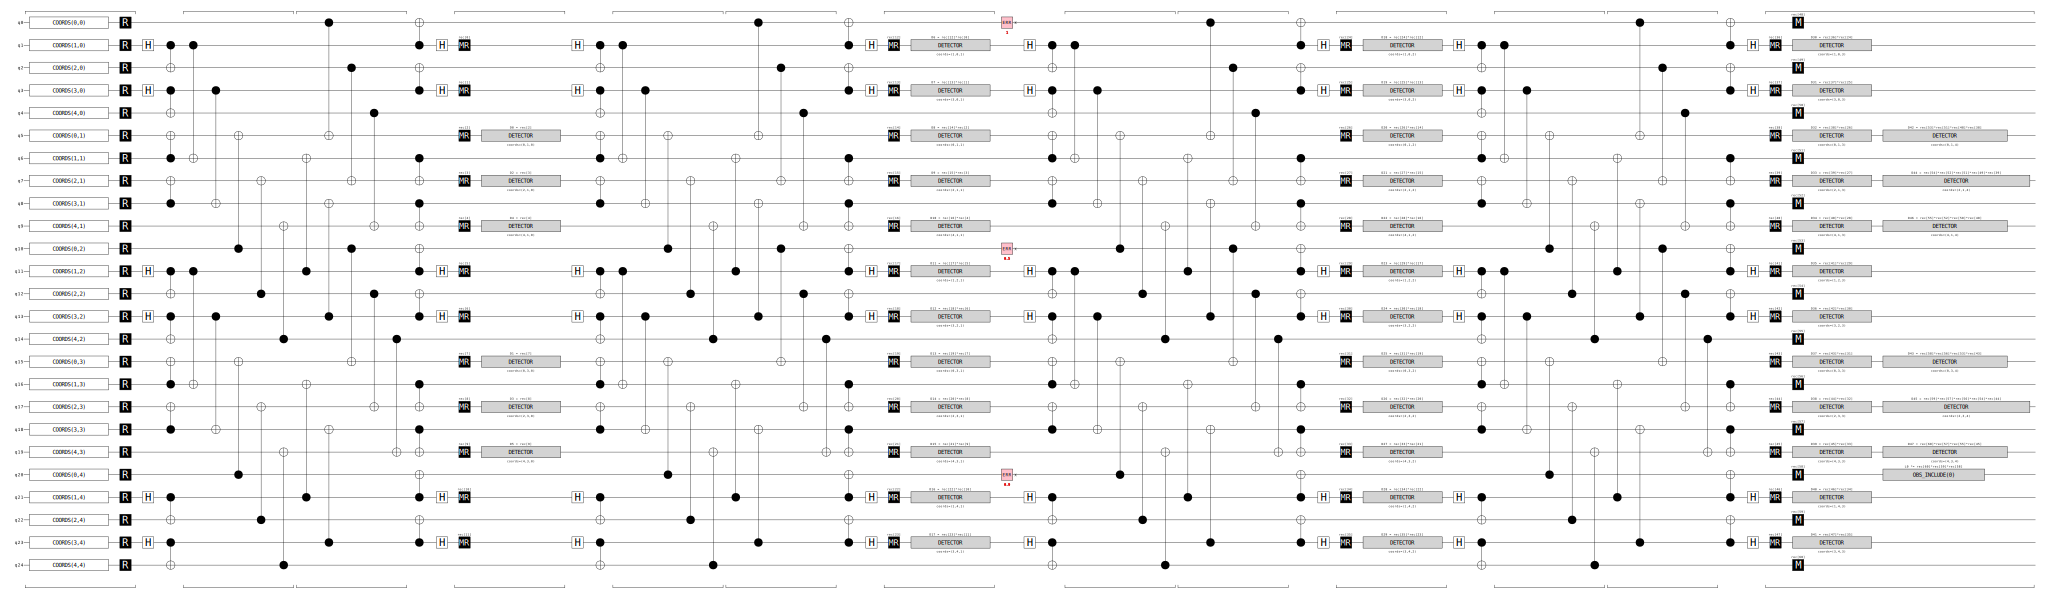

In [42]:
test = surface_code.diagram("timeline-svg")
test

[<re.Match object; span=(3453, 3489), match='M 0 2 4 6 8 10 12 14 16 18 20 22 24\n'>]


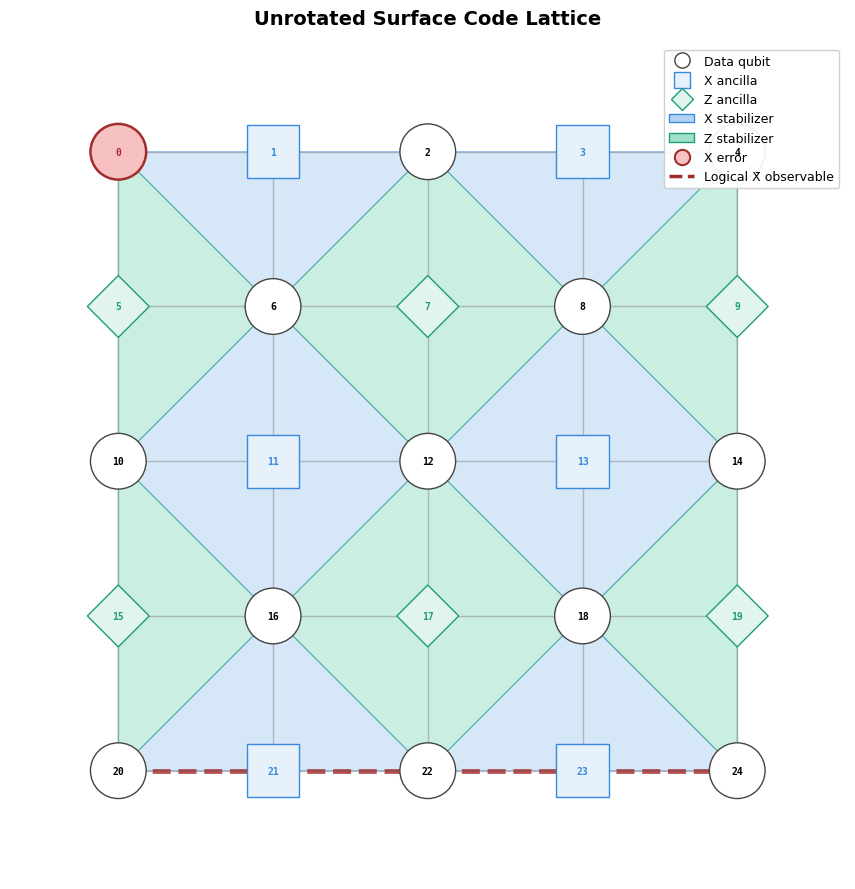

Figure(900x900)


In [43]:
print(plot_surface_code(surface_code))

# X Ancilla boundaries are smooth
# Z Ancilla boundaries are rough

In [44]:
obs = exec_mwpm(surface_code, 100, 1)



--- 100-shot batch decode ---
  Raw observable parities   : [0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1]
  Corrected logical outcomes: [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Logical error rate        : 0.94

  Raw = 1 on all shots  → X error flipped the logical Z.
  Corrected = 0         → MWPM identified and cancelled it.


In [24]:

# 1. Compile a sampler from your circuit
sampler = surface_code.compile_detector_sampler(seed=1)

# 2. Sample detection events and logical observables
# 'separate_observables=True' returns them in two distinct arrays
detectors, observables = sampler.sample(shots=10, separate_observables=True)

# 'observables' is a bit-packed numpy array of shape (shots, num_observables)

print(observables)

[[False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]]


In [101]:
sampler = surface_code.compile_sampler()
samples = sampler.sample(shots=10)
# Number of measurements per sample of the surface code
print(get_data_qubits(3, samples[0]))

for sample in samples:
    string = sample
    data_qubits = get_data_qubits(3, string)
    print_parity(data_qubits, s=5, f=8)

# stab_measurements = []
# for index in range(1, len(one_sample), 2):
#     stab_measurements.append(one_sample[index])
# print(stab_measurements)
# for k in range(0, len(one_sample), 24*5):
#     timeslice = one_sample[k:k+8]
#     print("".join("1" if e else "_" for e in timeslice))

[ True False  True False False  True False  True False False  True False
  True]
[ True False  True]
ones:6 zeros: 7 parity:0
[False  True  True]
ones:9 zeros: 4 parity:0
[ True False  True]
ones:7 zeros: 6 parity:0
[ True False  True]
ones:8 zeros: 5 parity:0
[ True False  True]
ones:6 zeros: 7 parity:0
[ True  True False]
ones:7 zeros: 6 parity:0
[False False False]
ones:6 zeros: 7 parity:0
[ True False  True]
ones:6 zeros: 7 parity:0
[ True  True False]
ones:10 zeros: 3 parity:0
[ True False  True]
ones:8 zeros: 5 parity:0


In [ ]:
detector_sampler = surface_code.compile_detector_sampler()
samples = detector_sampler.sample(shots=20)

print(samples[0])
# Number of detectors per sample
print(len(samples[0]))

# stab_measurements = []
# for index in range(1, len(one_sample), 2):
#     stab_measurements.append(one_sample[index])
# print(stab_measurements)


# for k in range(0, len(one_sample), 8):
#     timeslice = one_sample[k:k+8]
#     print("".join("!" if e else "_" for e in timeslice))
